In [1]:
import os
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

STOPWORDS = set(stopwords.words('english'))

## Reconstruct test set

In [2]:
df = pd.read_csv('../data/LabeledText.csv', encoding='latin-1')
df = df[['Caption', 'LABEL']].copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

df['clean'] = df['Caption'].apply(clean_text)

_, X_test, _, y_test = train_test_split(
    df['clean'], df['LABEL'],
    test_size=0.2,
    random_state=42,
    stratify=df['LABEL']
)

## Load models and evaluate

In [3]:
model_dir = '../models/text'
results = []

for fname in sorted(os.listdir(model_dir)):
    if not fname.endswith('.pkl'):
        continue
    model = joblib.load(os.path.join(model_dir, fname))
    y_pred = model.predict(X_test)
    results.append({
        'Model': fname.replace('.pkl', ''),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Macro F1
0,baseline,0.363,0.178


## Accuracy comparison

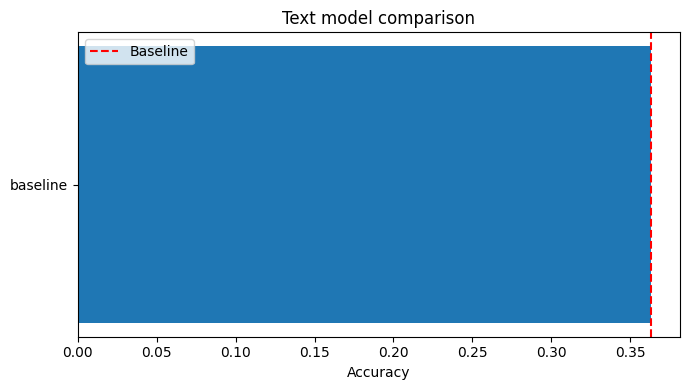

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(results_df['Model'], results_df['Accuracy'])
ax.axvline(results_df.loc[results_df['Model'] == 'baseline', 'Accuracy'].values[0],
           color='red', linestyle='--', label='Baseline')
ax.set_xlabel('Accuracy')
ax.set_title('Text model comparison')
ax.legend()
plt.tight_layout()
plt.show()